# 实战项目1：训练生成式问答模型

In [1]:
import random
import torch
import numpy as np
import os
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_scheduler
from tqdm.auto import tqdm
import json, sacrebleu
from torch.utils.tensorboard import SummaryWriter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


/root/miniconda3/envs/state1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# args:
dataset_size = 15_000
max_input_length = 512
max_target_length = 128

batch_size = 8
learning_rate = 2e-5
epoch_num = 10
log_step = 20
writer = SummaryWriter(log_dir='../tf-logs/t5QA/runs')

In [3]:
class QADataset(Dataset):
    def __init__(self, data_file):
        self.data = self.load_data(data_file)
    
    def load_data(self, data_file):
        Data = {}
        with open(data_file, 'rt', encoding='utf-8') as f:
            for idx, line in enumerate(f):
                if idx >= dataset_size:
                    break
                sample = json.loads(line.strip())
                Data[idx] = sample
        return Data
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [4]:
data = QADataset("./dataset/DuReaderQG/train.json")
train_size = int(len(data)*0.9)
valid_size = len(data) - train_size
train_data, valid_data = random_split(data, [train_size, valid_size])

print(f"训练数据集：{train_size}\n验证数据集{valid_size}")
print(f"取出一个样本{train_data[0]}")

训练数据集：13068
验证数据集1452
取出一个样本{'context': '一、卤牛肉最佳的时间是两个小时，这个时间卤出的牛肉吃到嘴里酥香可口，入口即化，还好消化。二、卤牛肉的制作方法：1、牛腱冲洗干净，切块后用清水浸泡半小时。2、冷水下锅，大火煮开，继续滚煮5至10分钟，充分去除血沫和异味。3、捞出用冷水冲洗干净，并用冷水浸泡10分钟，使肉质紧缩。4、各种香料冲洗净，入调味包，葱切段，姜切片备用。5、葱姜和香料包入锅，大火煮开，添加牛腱和料酒，大火煮开。6、添加生抽、老抽和黄豆酱，转中火慢炖半小时。7、然后转小火慢炖40分钟，添加盐糖调味，继续小火慢炖20分钟。8、能用筷子轻松插透牛腱时关火，捞出牛腱肉，放凉后，自然风干两小时。9、卤汁再次烧开，放入牛肉，用小火慢炖20分钟关火。10、取出即可食用，也可以让牛腱在卤水中多浸泡几小时更入味，也可以捞出入冰箱冷藏间保存，风味会更好。', 'answer': '两个小时', 'question': '卤牛肉要多久', 'id': 4155}


In [5]:
train_data[0]

{'context': '一、卤牛肉最佳的时间是两个小时，这个时间卤出的牛肉吃到嘴里酥香可口，入口即化，还好消化。二、卤牛肉的制作方法：1、牛腱冲洗干净，切块后用清水浸泡半小时。2、冷水下锅，大火煮开，继续滚煮5至10分钟，充分去除血沫和异味。3、捞出用冷水冲洗干净，并用冷水浸泡10分钟，使肉质紧缩。4、各种香料冲洗净，入调味包，葱切段，姜切片备用。5、葱姜和香料包入锅，大火煮开，添加牛腱和料酒，大火煮开。6、添加生抽、老抽和黄豆酱，转中火慢炖半小时。7、然后转小火慢炖40分钟，添加盐糖调味，继续小火慢炖20分钟。8、能用筷子轻松插透牛腱时关火，捞出牛腱肉，放凉后，自然风干两小时。9、卤汁再次烧开，放入牛肉，用小火慢炖20分钟关火。10、取出即可食用，也可以让牛腱在卤水中多浸泡几小时更入味，也可以捞出入冰箱冷藏间保存，风味会更好。',
 'answer': '两个小时',
 'question': '卤牛肉要多久',
 'id': 4155}

In [6]:
def seed_everything(seed=1029):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')
seed_everything(42)

Using cuda device


## 加载模型

In [7]:
check_point = "./model/mengzi-t5-base"
model = AutoModelForSeq2SeqLM.from_pretrained(check_point)
tokenizer = AutoTokenizer.from_pretrained(check_point)
model.to(device)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [8]:
def collate_fn(batch_samples):
    batch_inputs, batch_targets = [], []
    for sample in batch_samples:
        question = sample['question']
        context = sample['context']
        answer = sample['answer']
        
        input_text = f"context: {context} question: {question} "
        batch_inputs.append(input_text)
        batch_targets.append(answer)

    batch_data = tokenizer(
        batch_inputs,
        text_target=batch_targets,
        padding=True,
        truncation=True,
        max_length=max_input_length,
        return_tensors="pt"
    )

    # decoder_input_ids = model.prepare_decoder_input_ids_from_labels(labels)
    # end_token_index = torch.where(batch_data['labels'] == tokenizer.eos_token_id)[1]
    return batch_data

In [9]:
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
valid_dataloader = DataLoader(valid_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [10]:
batch = next(iter(train_dataloader))
print(batch.keys())
print('batch shape:', {k: v.shape for k, v in batch.items()})

KeysView({'input_ids': tensor([[    7, 25395,  7368,  ...,     0,     0,     0],
        [    7, 25395,  7368,  ...,     0,     0,     0],
        [    7, 25395,  7368,  ...,     0,     0,     0],
        ...,
        [    7, 25395,  7368,  ...,     0,     0,     0],
        [    7, 25395,  7368,  ...,     0,     0,     0],
        [    7, 25395,  7368,  ...,    50,   208,     1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1]]), 'labels': tensor([[    7,  7881,   840,     1,     0,     0,     0,     0,     0,     0],
        [    7,  1916,     1,     0,     0,     0,     0,     0,     0,     0],
        [    7,  9143,     1,     0,     0,     0,     0,     0,     0,     0],
        [    7,  1977,  4500,   547,     1,     0,     0,     0,     0,     0],
        [    7,   544,    38,   727,   614,    

In [11]:
def train_loop(dataloader, model, optimizer, lr_scheduler, epoch, total_loss):
    progress_bar = tqdm(range(len(dataloader)))
    progress_bar.set_description(f'loss: {0:>7f}')
    finish_batch_num = (epoch-1) * len(dataloader)
    
    model.train()
    for batch, batch_data in enumerate(dataloader, start=1):
        batch_data = batch_data.to(device)
        outputs = model(**batch_data)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()
        avg_loss = total_loss / (finish_batch_num + batch)

        # 写入 tensorboard
        global_step = finish_batch_num + batch
        if batch % log_step == 0:
            writer.add_scalar('train/avg_loss', avg_loss, global_step)      # 平均loss
            writer.add_scalar('train/batch_loss', loss.item(), global_step) # 瞬时loss
            writer.add_scalar('train/lr', lr_scheduler.get_last_lr()[0], global_step)

        progress_bar.set_description(f'loss: {loss.item():>7f} and avg_loss: {avg_loss:>7f}')
        progress_bar.update(1)
    return total_loss

In [12]:
def test_loop(dataloader, model):
    preds, labels = [], []
    weights_list = [
    (1., 0, 0, 0), # BLEU-1
    (0.5, 0.5, 0, 0), # BLEU-2
    (1/3, 1/3, 1/3, 0),  # BLEU-3
    (0.25, 0.25, 0.25, 0.25)    # BLEU-4
    ]

    model.eval()
    for batch_data in tqdm(dataloader):
        batch_data = batch_data.to(device)
        with torch.no_grad():
            generated_tokens = model.generate(
                batch_data["input_ids"],
                attention_mask=batch_data["attention_mask"],
                max_length=max_target_length,
            ).cpu().numpy()
        label_tokens = batch_data["labels"].cpu().numpy()
        
        decoded_preds = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
        label_tokens = np.where(label_tokens != -100, label_tokens, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(label_tokens, skip_special_tokens=True)

        preds += [pred.strip() for pred in decoded_preds]
        labels += [[label.strip() for label in decoded_labels]]
        
    smooth = SmoothingFunction().method2
    BLEUs = [ sentence_bleu(labels, preds, w, smooth) for w in weights_list]
    return BLEUs

In [13]:
optimizer = AdamW(model.parameters(), lr=learning_rate)
lr_scheduler = get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=0.1*epoch_num*len(train_dataloader),
    num_training_steps=epoch_num*len(train_dataloader),
)

total_loss = 0.
best_bleu = 0.
preds, labels = [], []

for t in range(epoch_num):
    print(f"Epoch {t+1}/{epoch_num}\n-------------------------------")
    total_loss = train_loop(train_dataloader, model, optimizer, lr_scheduler, t+1, total_loss)
    BLEUs = test_loop(valid_dataloader, model)

    print(f"BLEU 1~4 scores: {BLEUs[0]:>5f}, {BLEUs[1]:>5f}, {BLEUs[2]:>5f}, {BLEUs[3]:>5f}")

    if BLEUs[3] > best_bleu:
        best_bleu = BLEUs[3]
        print('Saving new best model...\n')
        torch.save(
            model.state_dict(), 
            f'epoch_{t+1}_valid_bleu_{BLEUs[3]:0.2f}_model_weights.bin'
        )
print("Done!")

Epoch 1/10
-------------------------------


loss: 0.144714 and avg_loss: 2.529587: 100%|█| 1634/1634 [04:16<00:00,  6.37it/s
100%|█████████████████████████████████████████| 182/182 [00:26<00:00,  6.84it/s]


BLEU 1~4 scores: 0.550275, 0.401330, 0.284295, 0.198006
Saving new best model...

Epoch 2/10
-------------------------------


loss: 0.049050 and avg_loss: 1.429969: 100%|█| 1634/1634 [04:22<00:00,  6.22it/s
100%|█████████████████████████████████████████| 182/182 [00:31<00:00,  5.70it/s]


BLEU 1~4 scores: 0.573003, 0.417644, 0.298386, 0.205849
Saving new best model...

Epoch 3/10
-------------------------------


...

BLEU 1~4 scores: 0.622590, 0.474457, 0.351947, 0.257398
Saving new best model...

Epoch 9/10
-------------------------------


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 182/182 [00:23<00:00,  7.72it/s]


BLEU 1~4 scores: 0.618457, 0.469717, 0.345826, 0.250479
Epoch 10/10
-------------------------------


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 182/182 [00:22<00:00,  7.93it/s]


BLEU 1~4 scores: 0.623278, 0.476975, 0.355687, 0.260330
Saving new best model...

Done!


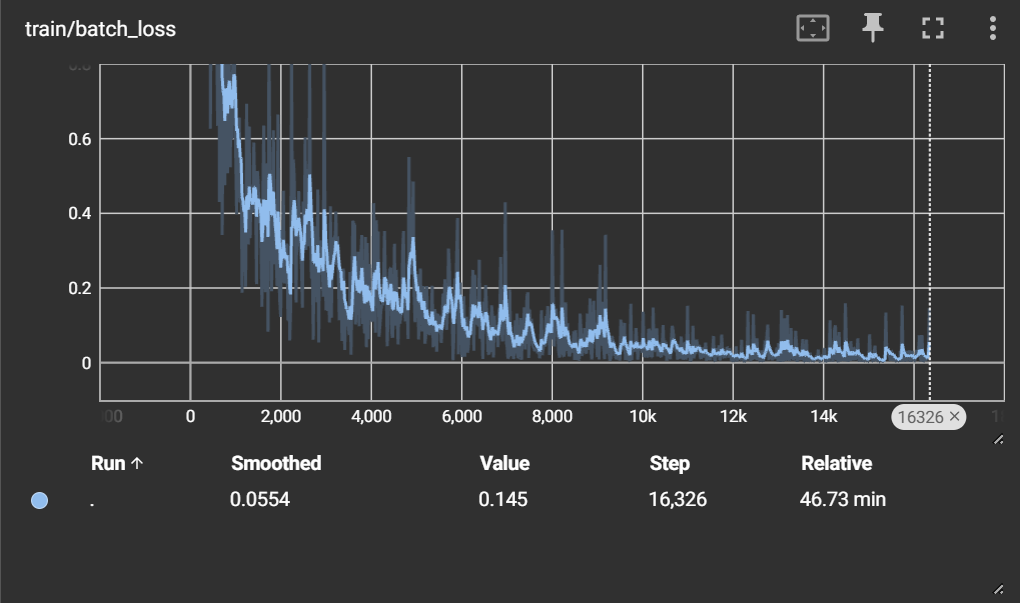

In [16]:
test_data = QADataset("./dataset/DuReaderQG/train.json")
# test, _ = random_split(test_data, [400, len(test_data)-400]) 
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)


model.load_state_dict(
    torch.load('epoch_10_valid_bleu_0.26_model_weights.bin', map_location=torch.device)
)
# tokenizer = AutoTokenizer.from_pretrained("Langboat/mengzi-t5-base")

<All keys matched successfully>

In [17]:
len(test_dataloader)

1815

直接使用test_loop进行验证集的测试

In [19]:
BLEU_test = test_loop(test_dataloader, model)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1815/1815 [03:56<00:00,  7.66it/s]


In [20]:
BLEU_test

[0.7949035812672176,
 0.7939388084680387,
 0.7421663663046999,
 0.6773553679789986]

或者可以自定义设置

In [21]:
weights_list = [
    (1., 0, 0, 0),               # BLEU-1
    (0.5, 0.5, 0, 0),            # BLEU-2
    (1/3, 1/3, 1/3, 0),          # BLEU-3
    (0.25, 0.25, 0.25, 0.25)     # BLEU-4
    ]
model.eval()
for batch_data in tqdm(test_dataloader):
    batch_data = batch_data.to(device)
    with torch.no_grad():
        generated_tokens = model.generate(
            batch_data["input_ids"],
            attention_mask=batch_data["attention_mask"],
            max_length=max_target_length,
        ).cpu().numpy()
    label_tokens = batch_data["labels"].cpu().numpy()
    
    decoded_preds = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
    label_tokens = np.where(label_tokens != -100, label_tokens, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(label_tokens, skip_special_tokens=True)

    preds += [pred.strip() for pred in decoded_preds]
    labels += [[label.strip() for label in decoded_labels]]
    
smooth = SmoothingFunction().method2
BLEUs = [ sentence_bleu(labels, preds, w, smooth) for w in weights_list]
print(f"BLEU 1~4 scores: {BLEUs[0]:>5f}, {BLEUs[1]:>5f}, {BLEUs[2]:>5f}, {BLEUs[3]:>5f}")

  5%|██                                       | 90/1815 [00:15<04:56,  5.82it/s]


KeyboardInterrupt: 

In [ ]:
preds, labels

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

weights_list = [
    (1., 0, 0, 0),               # BLEU-1
    (0.5, 0.5, 0, 0),            # BLEU-2
    (1/3, 1/3, 1/3, 0),          # BLEU-3
    (0.25, 0.25, 0.25, 0.25)     # BLEU-4
]

smooth = SmoothingFunction().method2
[ sentence_bleu(labels, preds, w, smooth) for w in weights_list], [ sentence_bleu(labels, preds, w) for w in weights_list]